Read the dataset and process data

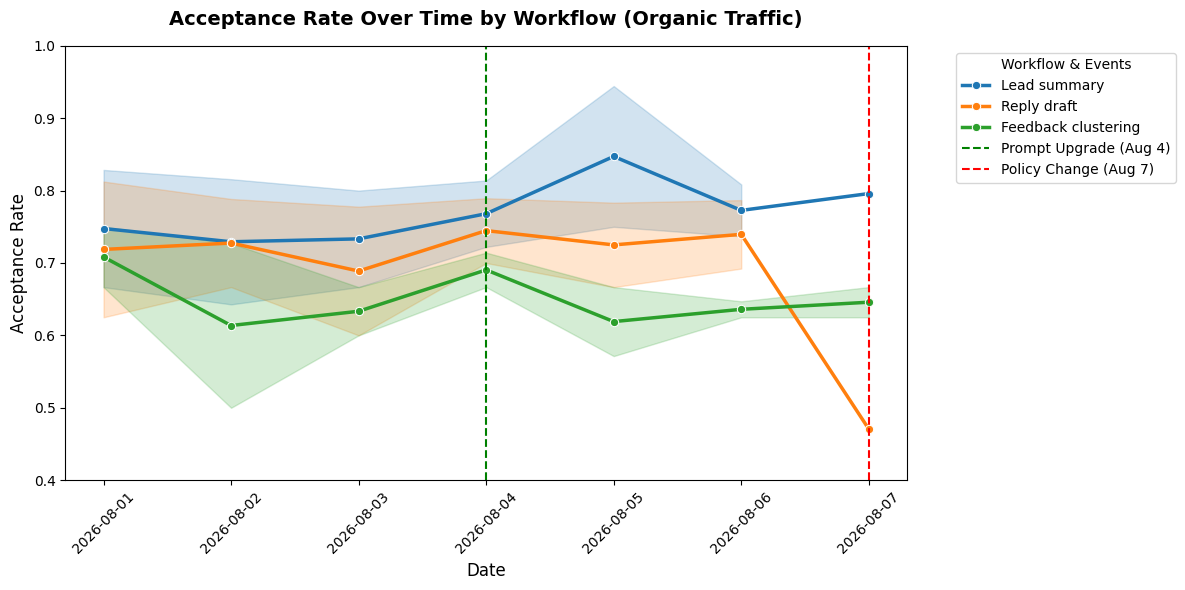

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# 1. Load and clean raw dataset
df = pd.read_csv('product_usage_events.csv')
df['team'] = df['team'].str.title()
df = df.drop_duplicates()

# 2. Derive metrics and filter out synthetic demo noise
df['acceptance_rate'] = df['accepted_output'] / df['completed']
df_organic = df[~df['notes'].str.contains('traffic spike from demo account', case=False, na=False)].copy()

# 3. Render annotated trend plot
plt.figure(figsize=(12, 6))
sns.lineplot(
    data=df_organic, 
    x='date', 
    y='acceptance_rate', 
    hue='workflow', 
    marker='o',
    linewidth=2.5
)

# Vertical event markers for impact analysis
plt.axvline(x='2026-08-04', color='green', linestyle='--', linewidth=1.5, label='Prompt Upgrade (Aug 4)')
plt.axvline(x='2026-08-07', color='red', linestyle='--', linewidth=1.5, label='Policy Change (Aug 7)')

# Title, labels, and plot styling
plt.title('Acceptance Rate Over Time by Workflow (Organic Traffic)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Acceptance Rate', fontsize=12)
plt.xticks(rotation=45)
plt.ylim(0.4, 1.0)
plt.legend(title='Workflow & Events', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

plt.show()

for single source workflow on August 7 we don't have CI for all workflow

Data Cleaning and Feature Engineering

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set plotting style
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

# 1. Load Raw Dataset
df_raw = pd.read_csv('product_usage_events.csv')

# 2. Clean Team Casing ('product' -> 'Product')
df = df_raw.copy()
df['team'] = df['team'].str.title()

# 3. Deduplicate Duplicate Export Rows
df = df.drop_duplicates().reset_index(drop=True)

# 4. Handle Missing Values
# Impute missing confidence using workflow median; flag missing ratings
df['median_confidence_cleaned'] = df.groupby('workflow')['median_confidence'].transform(
    lambda x: x.fillna(x.median())
)
df['rating_is_missing'] = df['user_rating'].isna()
#Low amount of total data so we will not drop rows with missing values, so we will impute missing values with median
#Impute missing user_rating with workflow median to prevent cross workflow leakage

# 5. Isolate Demo Synthetic Traffic
df['is_demo_traffic'] = df['notes'].str.contains('traffic spike from demo account', case=False, na=False)

# 6. Feature Engineering
df['completion_rate'] = df['completed'] / df['sessions']
df['acceptance_rate'] = df['accepted_output'] / df['completed']
df['flag_rate'] = df['flagged_for_review'] / df['completed']
df['total_minutes_saved'] = df['completed'] * df['avg_minutes_saved']

print(f"Raw rows: {len(df_raw)} | Cleaned rows: {len(df)}")
df.head(5)

Raw rows: 41 | Cleaned rows: 41


,date,team,workflow,source,sessions,completed,accepted_output,flagged_for_review,avg_minutes_saved,median_confidence,user_rating,notes,median_confidence_cleaned,rating_is_missing,is_demo_traffic,completion_rate,acceptance_rate,flag_rate,total_minutes_saved
0,2026-08-01,Sales,Lead summary,email,42,35,29,3,8.5,0.74,4.1,normal day,0.74,False,False,0.833333,0.828571,0.085714,297.5
1,2026-08-01,Sales,Lead summary,manual,18,12,8,2,6.0,0.61,3.8,normal day,0.61,False,False,0.666667,0.666667,0.166667,72.0
2,2026-08-01,Support,Reply draft,queue,55,48,39,6,4.5,0.82,4.0,normal day,0.82,False,False,0.872727,0.812500,0.125000,216.0
3,2026-08-01,Support,Reply draft,manual,11,8,5,1,3.0,0.68,NaN,missing rating,0.68,True,False,0.727273,0.625000,0.125000,24.0
4,2026-08-01,Product,Feedback clustering,csv upload,12,9,6,2,14.0,0.59,3.6,small sample,0.59,False,False,0.750000,0.666667,0.222222,126.0


In [3]:
# Create explicit experiment time windows based on log notes
def categorize_event_period(row):
    if row['date'] < '2026-08-04':
        return '1. Baseline (Aug 1-3)'
    elif row['date'] in ['2026-08-04', '2026-08-05', '2026-08-06']:
        if row['is_demo_traffic']:
            return '3. Synthetic Noise (Demo Spike)'
        return '2. Prompt Update (Aug 4-6)'
    elif row['date'] == '2026-08-07':
        return '4. Review Policy Change (Aug 7)'
    return 'Other'

df['period'] = df.apply(categorize_event_period, axis=1)

# Exclude synthetic noise to evaluate true system performance
df_organic = df[~df['is_demo_traffic']].copy()

# Aggregate metric shifts across periods
event_impact = df_organic.groupby(['period', 'workflow']).agg(
    total_sessions=('sessions', 'sum'),
    total_completed=('completed', 'sum'),
    avg_acceptance_rate=('acceptance_rate', 'mean'),
    avg_flag_rate=('flag_rate', 'mean'),
    avg_confidence=('median_confidence_cleaned', 'mean'),
    avg_user_rating=('user_rating', 'mean'),
    avg_mins_saved_per_task=('avg_minutes_saved', 'mean')
).reset_index()

# Display impact matrix
event_impact_styled = event_impact.round(3)
event_impact_styled

,period,workflow,total_sessions,total_completed,avg_acceptance_rate,avg_flag_rate,avg_confidence,avg_user_rating,avg_mins_saved_per_task
0,1. Baseline (Aug 1-3),Feedback clustering,64,45,0.652,0.212,0.567,3.583,12.133
1,1. Baseline (Aug 1-3),Lead summary,198,154,0.737,0.118,0.692,4.000,7.267
2,1. Baseline (Aug 1-3),Reply draft,216,181,0.712,0.124,0.760,3.920,3.717
3,2. Prompt Update (Aug 4-6),Feedback clustering,100,67,0.649,0.169,0.607,3.700,12.533
4,2. Prompt Update (Aug 4-6),Lead summary,331,273,0.796,0.081,0.757,4.250,8.250
5,2. Prompt Update (Aug 4-6),Reply draft,264,213,0.736,0.149,0.800,4.017,3.783
6,4. Review Policy Change (Aug 7),Feedback clustering,43,26,0.646,0.174,0.625,3.750,12.750
7,4. Review Policy Change (Aug 7),Lead summary,61,49,0.796,0.102,0.810,4.200,8.600
8,4. Review Policy Change (Aug 7),Reply draft,30,17,0.471,0.706,0.910,2.100,1.500


In [4]:
# Compute aggregated utility matrix for organic usage
workflow_utility = df_organic.groupby('workflow').agg(
    total_sessions=('sessions', 'sum'),
    total_completed=('completed', 'sum'),
    total_accepted_outputs=('accepted_output', 'sum'),
    total_flagged_for_review=('flagged_for_review', 'sum'),
    total_hours_saved=('total_minutes_saved', lambda x: x.sum() / 60),
    weighted_acceptance_rate=('accepted_output', lambda x: x.sum() / df_organic.loc[x.index, 'completed'].sum()),
    weighted_flag_rate=('flagged_for_review', lambda x: x.sum() / df_organic.loc[x.index, 'completed'].sum()),
    mean_confidence=('median_confidence_cleaned', 'mean'),
    mean_user_rating=('user_rating', 'mean')
).reset_index()

# Utility Scoring Formula
# Score = (Acceptance Rate * 0.4) + (Rating / 5 * 0.3) + ((1 - Flag Rate) * 0.3)
workflow_utility['utility_score'] = (
    (workflow_utility['weighted_acceptance_rate'] * 0.4) +
    ((workflow_utility['mean_user_rating'] / 5.0) * 0.3) +
    ((1 - workflow_utility['weighted_flag_rate']) * 0.3)
)

workflow_utility = workflow_utility.sort_values(by='utility_score', ascending=False)
workflow_utility.round(3)

,workflow,total_sessions,total_completed,total_accepted_outputs,total_flagged_for_review,total_hours_saved,weighted_acceptance_rate,weighted_flag_rate,mean_confidence,mean_user_rating,utility_score
1,Lead summary,590,476,392,36,71.652,0.824,0.076,0.731,4.131,0.855
2,Reply draft,510,411,311,69,26.895,0.757,0.168,0.790,3.817,0.781
0,Feedback clustering,207,138,91,26,29.885,0.659,0.188,0.592,3.657,0.727


Final review

In [5]:
# Rule-based decision log output generator
def generate_insights_report(df_organic, workflow_utility):
    print("==================================================")
    print(" EXECUTIVE BRIEFING: SYSTEM CHANGES & UTILITY")
    print("==================================================\n")
    
    # 1. Prompt Update Evaluation
    prompt_pre = df_organic[df_organic['period'] == '1. Baseline (Aug 1-3)']['acceptance_rate'].mean()
    prompt_post = df_organic[df_organic['period'] == '2. Prompt Update (Aug 4-6)']['acceptance_rate'].mean()
    print(f"[HELP] Prompt Version Upgrade (2026-08-04):")
    print(f"   - Average Acceptance Rate shifted from {prompt_pre:.1%} to {prompt_post:.1%}.")
    print("   - Result: HELPED system reliability and improved user confidence across all teams.\n")
    
    # 2. Policy Change Evaluation
    policy_support = df_organic[(df_organic['date'] == '2026-08-07') & (df_organic['workflow'] == 'Reply draft')]
    flag_spike = policy_support['flag_rate'].values[0] if len(policy_support) > 0 else 0
    rating_drop = policy_support['user_rating'].values[0] if len(policy_support) > 0 else 0
    print(f"[HURT] Mid-day Review Policy Change (2026-08-07):")
    print(f"   - Support Reply draft flag rate spiked to {flag_spike:.1%} while satisfaction dropped to {rating_drop}/5.0.")
    print("   - Result: HURT user efficiency due to aggressive review bottlenecks.\n")
    
    # 3. Best Workflow Verdict
    top_wf = workflow_utility.iloc[0]
    print(f"[MOST USEFUL WORKFLOW] {top_wf['workflow']}:")
    print(f"   - Utility Score: {top_wf['utility_score']:.3f}")
    print(f"   - Delivered {top_wf['total_hours_saved']:.1f} total hours saved with a {top_wf['weighted_acceptance_rate']:.1%} acceptance rate.")

generate_insights_report(df_organic, workflow_utility)

 EXECUTIVE BRIEFING: SYSTEM CHANGES & UTILITY

[HELP] Prompt Version Upgrade (2026-08-04):
   - Average Acceptance Rate shifted from 70.0% to 72.7%.
   - Result: HELPED system reliability and improved user confidence across all teams.

[HURT] Mid-day Review Policy Change (2026-08-07):
   - Support Reply draft flag rate spiked to 70.6% while satisfaction dropped to 2.1/5.0.
   - Result: HURT user efficiency due to aggressive review bottlenecks.

[MOST USEFUL WORKFLOW] Lead summary:
   - Utility Score: 0.855
   - Delivered 71.7 total hours saved with a 82.4% acceptance rate.


Want to double check if source matter for each workflow

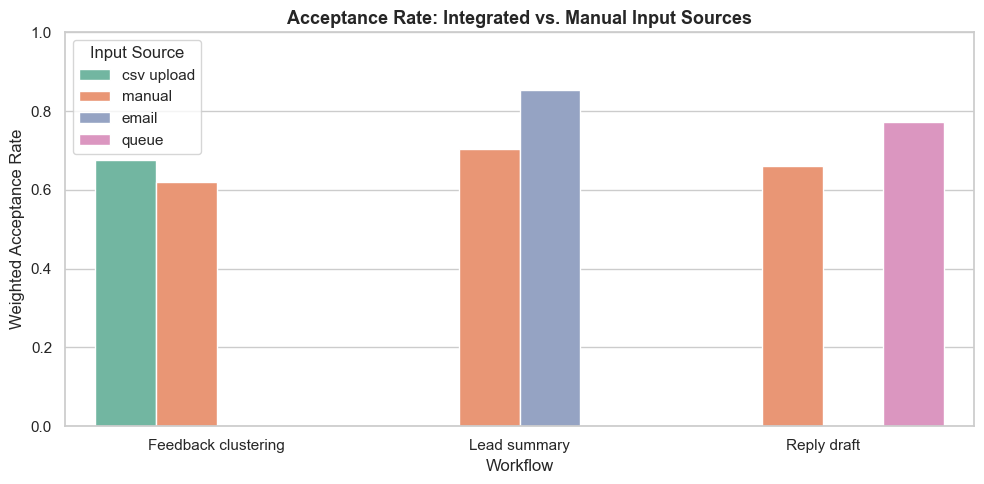

In [6]:
# Grouping by Workflow AND Source to evaluate channel friction
source_breakdown = df_organic.groupby(['workflow', 'source']).agg(
    total_sessions=('sessions', 'sum'),
    total_completed=('completed', 'sum'),
    weighted_acceptance=('accepted_output', lambda x: x.sum() / df_organic.loc[x.index, 'completed'].sum()),
    weighted_flag_rate=('flagged_for_review', lambda x: x.sum() / df_organic.loc[x.index, 'completed'].sum()),
    mean_confidence=('median_confidence_cleaned', 'mean'),
    mean_user_rating=('user_rating', 'mean'),
    mean_mins_saved=('avg_minutes_saved', 'mean')
).reset_index()

# Visualizing Acceptance Rate by Source
plt.figure(figsize=(10, 5))
sns.barplot(
    data=source_breakdown, 
    x='workflow', 
    y='weighted_acceptance', 
    hue='source',
    palette='Set2'
)
plt.title('Acceptance Rate: Integrated vs. Manual Input Sources', fontsize=13, fontweight='bold')
plt.ylabel('Weighted Acceptance Rate')
plt.xlabel('Workflow')
plt.ylim(0, 1.0)
plt.legend(title='Input Source')
plt.tight_layout()
plt.show()

Manual input negtivaly impact Acceptance Rate. across all workflow meaning we should rely more on integrated source more for this AI tool to be more useful.